# Cam design exercise
Based on a given numeric specification for a cam mechanism, a plausible usage is gonna be matched and an optimalisation of the cam is gonna be made, based on this usage.


## Numerical specification
Specification sheet 49

The cam to design must realise underneath lifts :

- from 30° to 120° : +40 mm
- from 180° tot 240° : -20 mm
- from 250° tot 330° : -20 mm

The equivalent mass and dampingsconstant of the follower (and associated parts) are respectively estimated at 15 kg en 0.054, while the mechanism must exerce following static forces:

- from 30° to 180° : a constant pressure force of 95 N
- from 180° to 240° : a constant pulling force of 20 N
- from 240° to 330° : a linear decreasing pulling force from 20 N to 0 N 

The demanded cycletime of the process delivered by the follower is 2 s.

This means 30 rpm on the cam.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

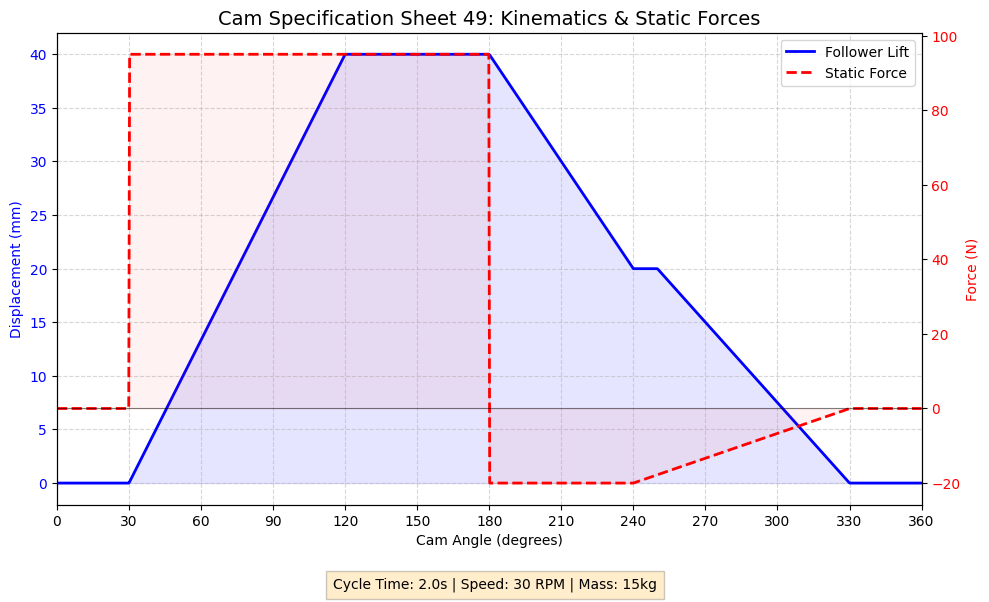

In [3]:
# --- Configuration & Data ---
angle = np.linspace(0, 360, 1000)  # Full rotation in degrees
rpm = 30
cycle_time = 60 / rpm  # 2.0 seconds

# 1. Lift Profile (Displacement in mm)
lift = np.zeros_like(angle)
lift[(angle >= 30) & (angle <= 120)] = np.interp(angle[(angle >= 30) & (angle <= 120)], [30, 120], [0, 40])
lift[(angle > 120) & (angle <= 180)] = np.interp(angle[(angle > 120) & (angle <= 180)], [120, 180], [40, 40])
lift[(angle > 180) & (angle <= 240)] = np.interp(angle[(angle > 180) & (angle <= 240)], [180, 240], [40, 20])
lift[(angle > 240) & (angle <= 250)] = 20 # Dwell
lift[(angle > 250) & (angle <= 330)] = np.interp(angle[(angle > 250) & (angle <= 330)], [250, 330], [20, 0])
lift[angle > 330] = 0

# 2. Static Force Profile (N)
force = np.zeros_like(angle)
force[(angle >= 30) & (angle <= 180)] = 95
force[(angle > 180) & (angle <= 240)] = -20
force[(angle > 240) & (angle <= 330)] = np.interp(angle[(angle > 240) & (angle <= 330)], [240, 330], [-20, 0])

# --- Plotting with Dual Y-Axes ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary Axis (Left): Displacement
ax1.set_xlabel('Cam Angle (degrees)', fontsize=10)
ax1.set_ylabel('Displacement (mm)', fontsize=10, color='blue')
line1, = ax1.plot(angle, lift, color='blue', lw=2, label='Follower Lift')
ax1.fill_between(angle, lift, color='blue', alpha=0.1)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.5)

# Secondary Axis (Right): Force
ax2 = ax1.twinx()  
ax2.set_ylabel('Force (N)', fontsize=10, color='red')
line2, = ax2.plot(angle, force, color='red', lw=2, linestyle='--', label='Static Force')
ax2.fill_between(angle, force, color='red', alpha=0.05)
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(0, color='black', lw=0.8, alpha=0.5) # Zero line

# Formatting
plt.title('Cam Specification Sheet 49: Kinematics & Static Forces', fontsize=14)
plt.xticks(np.arange(0, 361, 30))
plt.xlim(0, 360)

# Combined Legend
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

# Annotation for the Cycletime
plt.figtext(0.5, 0.01, f"Cycle Time: {cycle_time}s | Speed: {rpm} RPM | Mass: 15kg", 
ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

The exact path between the lifts has to be designed further. The goal of above graph is to illustrate relation between lift and external load. In the follower displacement we see two active dwell faces. The pressure load begins to act when starting first displacement and continues to act till downlift. When downlifting a net pulling force is acting till the follower is down 20 mm. After that this force is linearly decreasing till zero, while the second downlift is not yet started! Load and displacement are not related anymore.

## Plausible usage

<figure>
  <img src="../figures/Ionized_air_cleaner.gif" width="800">
</figure>

Above animation shows the process of an ionized air container cleaner. The head comes down to close the seals around the container openings. Afterwards ionized, compressed air is injected via a central nozzle into the container. This creates a slight overpressure. Ionization of the air helps detaching dust molecules from the borders of the container. Then little underpressure is created to remove this dust particles from the container via tubes in the head. The head is lifted up. 

To make it in lign with the given specifications:
- 40 mm downlift of the head: container is being sealed
- First dwell to let the ionized air do its work: force of +95 N due to overpressure
- First 20 mm uplift to unseal the container: force of -20 N needed (suction)
- Second dwell for check-up: begin pressure equalization (-20 N to 0 N)
- Second 20 mm uplift to bring the head back to initial position

For modelling we consider a total +95 N load already while doing the downlift. As the given equivalent mass is 15 kg, we can consider a mechanism doing 8 containers at the time. If we consider containers with a 60 mm diameter seal, the loads correspond to an overpressure of 42 mbar and underpressure of 8.8 mbar. These values depend on effective pressure area.


## Initialization of design and simulation variables

In [4]:
# Simulation variables of cam:

dtheta = 0.01 # resolution of simulation, in degrees

theta_deg      = np.arange(0,360,dtheta) # array of cam angles in degrees
theta          = theta_deg*np.pi/180     # array of cam angles in radians
lift           = np.zeros(len(theta))    # lift follower in mm
vel            = np.zeros(len(theta))    # velocity follower in mm/rad
vel_deg        = np.zeros(len(theta))    # velocity follower in mm/degree
acc            = np.zeros(len(theta))    # acceleration follower in mm/rad^2
acc_deg        = np.zeros(len(theta))    # acceleration follower in mm/degree^2
ext_load       = np.zeros(len(theta))    # external load in N
pressure_angle = np.zeros(len(theta))    # pressure angle in radians

# Cam design parameters, as output of the analysis
base_radius     = [] # base circle radius in mm
follower_radius = [] # follower radius in mm
exc             = [] # excentricity in mm
mass            = [] # equivalent mass in kg
spring_constant = [] # spring constant in N/mm
spring_preload  = [] # spring preload in N
rpm             = [] # rotations per minute of the cam
omega           = [] # angular velocity of the cam in rad/s

# search space of possible R0 values [mm]:
R0_min          =   0
R0_max          = 100 
R0_delta        =   0.1 
R0_vec          = np.arange(R0_min, R0_max, R0_delta) 
# maximum pressure angle corresponding to the evaluated R0s:
alpha_max       = np.zeros_like(R0_vec)

beta_vec        = np.arange(1, 360, 0.1)  # sampling resolution for rotation
rho_min         = np.zeros_like(beta_vec) # minimal follower radius at each beta

# input parameters of several analysis functions:
beta            = [] # cam angle interval of the segment
startangle      = [] # start angle of the segment in degrees
endangle        = [] # end angle of the segment in degrees
startlift       = [] # start lift of the segment in mm
endlift         = [] # end lift of the segment in mm
startangleload  = [] # start angle of the load in degrees
endangleload    = [] # end angle of the load in degrees
startload       = [] # start load in N
endload         = [] # end load in N
motionlaw       = [] # choice of motion law:
    # 1: dwell,
	  # 2: minimal rms acceleration,
	  # 3: harmonic,
	  # 4: cycloid,
	  # 5: 5th degree poly,
	  # 6: 7th degree poly

## Choosing the motionlaws

<div style=" display: grid; place-items: center; place-content: center;">
 <img style="border: 0; display: inline-block;" height="100%"
      src="../figures/motion-law-summary.png"
 >
</div>

For a controlled cleaning process it's important that the sealing is well realised and is uniformly over the 8 containers. Each container has also a threaded finish at the top that must not be damaged/deformed during the process. Additionally the polymer seal on the follower head is subject to fatigue, tearing, edge wear and deformation that could impact sealing efficiency. Minimizing this would mean a longer lifetime for the follower head. 

For above reasons it is more likely to choose a 7th degree polynomial motion. This way we have finite acceleration, jerk and Djerk, so that seating and release are gentler. It reduces seal slap and wear, eventual leakage and uneven seating. At the same time compaired with min Djerk, it keeps peak velocity, acceleration and jerk lower. 

If the second 20 mm uplift is contactless with the container, a less smooth motion law can be chosen for that segment, but that is not our case. Therefore a 7th degree polynomial is chosen for all the lift segments. The higher manufacturing and energy supply cost is expected to be outweighed by the lower lifetime/replacement cost of the follower head and smaller risk of thread damage on the containers. Additionally a more reliable cleaning process can be delivered. 

Now that the motion laws have been chosen, the specefications can be attributed underneath. 

In [5]:
# specifications:

startangle1 = 30 # degrees
endangle1   = 120 # degrees
theta_seg1  = endangle1 - startangle1 # rotation length for first motion segment
startlift1  =  0
endlift1    = 40
motionlaw1  =  6

startangle2 =  120 # degrees
endangle2   = 180 # degrees
theta_seg2  = endangle2 - startangle2 # rotation length for second segment
startlift2  = 40
endlift2    =  40
motionlaw2  =   6

startangle3 = 180 # degrees
endangle3   = 240 # degrees
theta_seg3  = endangle3 - startangle3 # rotation length for third segment
startlift3  =  40
endlift3    =  20
motionlaw3  =   6

startangle4 = 240 # degrees
endangle4   = 250 # degrees
theta_seg4  = endangle4 - startangle4 # rotation length for fourth segment
startlift4  =  20
endlift4    =   20
motionlaw4  =   6

startangle5 = 250 # degrees
endangle5   = 330 # degrees
theta_seg5  = endangle5 - startangle5 # rotation length for fourth segment
startlift5  =  20
endlift5    =   0
motionlaw5  =   6

startangleload1 =   30
endangleload1   =   180
startload1      =    95
endload1        =  95

startangleload2 =   180
endangleload2   =  240
startload2      =  -20
endload2        =   -20

startangleload3 =  240
endangleload3   =  300
startload3      = -20
endload3        = 0

The radial cam lift, velocity and acceleration are computed and plotted against the rotation angle of the cam. 

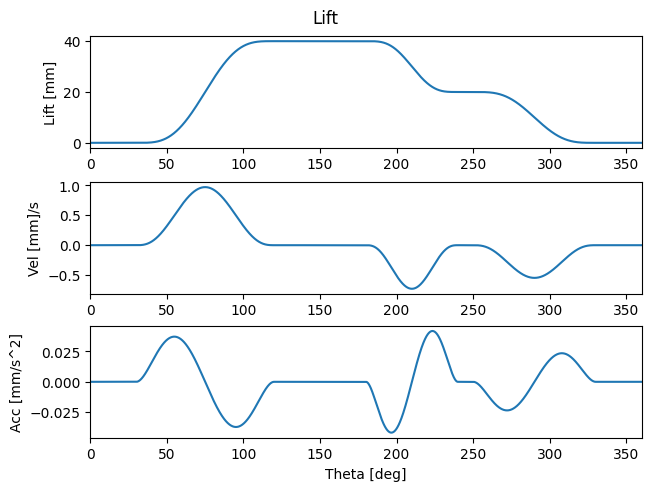

In [6]:
# compute motion functions:

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2

    return lift, vel_deg, acc_deg, vel, acc

def plotMotionLaw(t,lift,vel,acc):
    fig1, ax1 = plt.subplots(nrows=3,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Vel [mm]/s")
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acc [mm/s^2]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])


# Add all four segments to the motion law:
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle1,endangle1,startlift1,endlift1,motionlaw1,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle2,endangle2,startlift2,endlift2,motionlaw2,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle3,endangle3,startlift3,endlift3,motionlaw3,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle4,endangle4,startlift4,endlift4,motionlaw4,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle5,endangle5,startlift5,endlift5,motionlaw5,dtheta)


# Plot the motion law
plotMotionLaw(theta_deg,lift,vel_deg,acc_deg)

plt.show()

## Cam-follower geometry
### Pressure angle and pitch radius
Designing the geometry starts by finding the value of the pitch radius $R_0$ which ensures an acceptable value of the pressure angle along the whole cam motion. The function _Kloomok_Muffley_R0_  substitutes the Kloomok and Muffley nomogram presented in the lecture, allowing a more precise evaluation of $R_0$ and allowing a larger choice of motion laws. The function plots the maximum pressure angle as a function of $R_0$ for a specific segment (defined by the cam angle interval $\beta$, the start and end lift of the segment and the chosen type of motion law from the previous step). The plot can be used to find the maximum value of $R_0$ allowable for a specific dataset.

In [7]:
# utility functions for cam profile design (with eccentricity = 0!)

# relate sampled R0 values to pressure angle \alpha:
def Kloomok_Muffley_R0(beta,startlift,endlift,motionlaw, alpha_opt= 30):
    global R0_vec, alpha_max
    L0 = startlift
    L1 = endlift
    beta = beta * np.pi / 180
		# 100 samples in dimensionless "arc length" of motion law:
    x = np.arange(0, 1, 0.01)

    for i in range(len(R0_vec)):
        R0 = R0_vec[i]

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        alpha = np.arctan2(vel_ang, R0 + lift)
        alpha_max[i] = np.max(np.abs(alpha)) * 180 / np.pi

        if np.isclose(alpha_max[i], alpha_opt, atol=0.1):
            print(f'R0 when alpha_max is approximately {alpha_opt}°: {R0:.2f} mm')
     
    plt.figure()
    plt.plot(R0_vec, alpha_max)
    plt.grid()
    plt.xlabel('$R_0$ (mm)')
    plt.ylabel(r'$\alpha_{max}$ (degree)')
    plt.axhline(y=alpha_opt, color='r', linestyle='--', label=f'y={alpha_opt}')
    plt.xlim([0, 100])
    plt.show()

R0 when alpha_max is approximately 30°: 77.80 mm
R0 when alpha_max is approximately 30°: 77.90 mm
R0 when alpha_max is approximately 30°: 78.00 mm
R0 when alpha_max is approximately 30°: 78.10 mm
R0 when alpha_max is approximately 30°: 78.20 mm
R0 when alpha_max is approximately 30°: 78.30 mm
R0 when alpha_max is approximately 30°: 78.40 mm
R0 when alpha_max is approximately 30°: 78.50 mm


<Figure size 640x480 with 0 Axes>

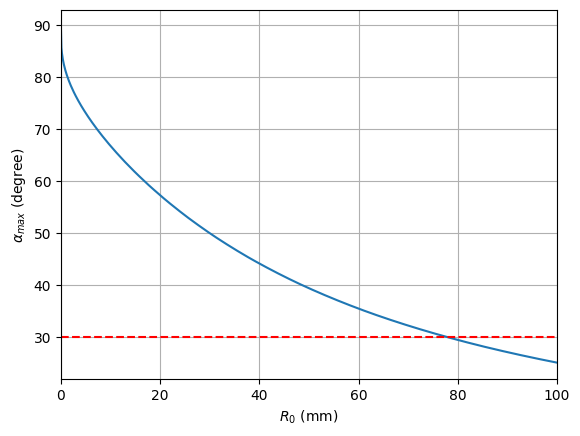

R0 when alpha_max is approximately 30°: 42.70 mm
R0 when alpha_max is approximately 30°: 42.80 mm
R0 when alpha_max is approximately 30°: 42.90 mm
R0 when alpha_max is approximately 30°: 43.00 mm
R0 when alpha_max is approximately 30°: 43.10 mm


<Figure size 640x480 with 0 Axes>

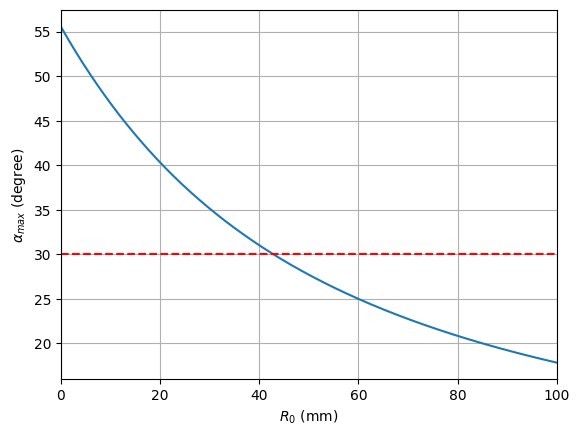

R0 when alpha_max is approximately 30°: 44.80 mm
R0 when alpha_max is approximately 30°: 44.90 mm
R0 when alpha_max is approximately 30°: 45.00 mm
R0 when alpha_max is approximately 30°: 45.10 mm
R0 when alpha_max is approximately 30°: 45.20 mm


<Figure size 640x480 with 0 Axes>

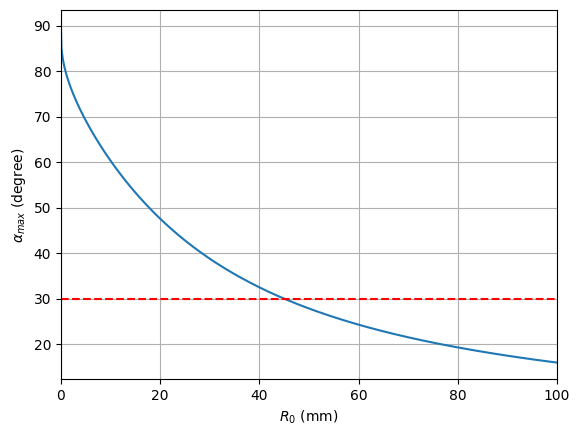

In [8]:
# Use the first Kloomok and Muffley figure to choose the pitch radius R0
alpha_opt = 30 # limit to optimize for
# Segment 1: van 30° tot 120° : +40 mm
beta = endangle1 - startangle1  # cam angle interval in degrees
startlift = startlift1  # start lift in mm
endlift = endlift1 # end lift in mm
motionlaw = motionlaw1 # choice of motion law (1: dwell, 2: minimal rms acceleration, 3: harmonic, 4: cycloid, 5: 5th degree poly, 6: 7th degree poly)
# Plot the figure of segment 1
plt.figure(num = 'Kloomok and Muffley - segment 1')
Kloomok_Muffley_R0(beta,startlift,endlift,motionlaw, alpha_opt)

# Segment 3 (skipping dwel segment 2): van 180° tot 240° : -20 mm
beta = endangle3 - startangle3 # cam angle interval in degrees
startlift = startlift3  # start lift in mm
endlift = endlift3 # end lift in mm
motionlaw = motionlaw3 # choice of motion law (1: dwell, 2: minimal rms acceleration, 3: harmonic, 4: cycloid, 5: 5th degree poly, 6: 7th degree poly)
# Plot the figure of segment 3
plt.figure(num = 'Kloomok and Muffley - segment 3')
Kloomok_Muffley_R0(beta,startlift,endlift,motionlaw, alpha_opt)

# Segment 5 (skipping dwel segment 4): van 250° tot 330° : -20 mm
beta = endangle5 - startangle5 # cam angle interval in degrees
startlift = startlift5  # start lift in mm
endlift = endlift5 # end lift in mm
motionlaw = motionlaw5 # choice of motion law (1: dwell, 2: minimal rms acceleration, 3: harmonic, 4: cycloid, 5: 5th degree poly, 6: 7th degree poly)
# Plot the figure of segment 5
plt.figure(num = 'Kloomok and Muffley - segment 5')
Kloomok_Muffley_R0(beta,startlift,endlift,motionlaw, alpha_opt)

We are chosing $R_0$ such that the pressure angle of every segment stays below 30°, which is preferable for translational followers. Above plots gives us the underlimits for $R_0$ for every segment:
- Segment 1 =>  $78.5$ mm
- Segment 3 =>  $43.1$ mm
- Segment 5 =>  $45.2$ mm

Ensuring the condition for every segment, gives us an $R_0 > 78.5 mm$. Therefore we choose an $R_0$ of 90 mm.

In [9]:
R0 = 90 #mm

### Undercutting and follower radius

Once the pitch radius $R_0$ is chosen, the function _Kloomok_Muffley_follower_radius_ defined below allows to create the figure showing the minimum radius of curvature of the pitch curve $\rho_{min}$ as a function of the active cam angle $\beta$ (i.e. the cam angle interval) for a specific segment.
As a reminder, the radius of curvature of the pitch curve is defined as:

$\rho = \frac{((R_0+f(\theta))^2+(f'(\theta))^2)^{\frac{3}{2}}}{(R_0+f(\theta))^2+2(f'(\theta))^2-(R_0+f(\theta))\cdot f''(\theta)}$

Thus, the condition $\rho_{\text{min}} \gt R_r$ to prevent undercutting can be used to choose the follower radius.

In [10]:
# relate given R0 value to samples of curvature radii of motion law:
def Kloomok_Muffley_follower_radius(R0,startlift,endlift,motionlaw, target_beta):
    global beta_vec, rho_min
    L0 = startlift
    L1 = endlift

    for i in range(len(beta_vec)):
        beta = beta_vec[i] * np.pi / 180
        theta = np.linspace(0, beta_vec[i], 100) * np.pi / 180
        x = theta / beta

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        rho = ((R0 + lift)**2 + vel_ang**2)**(3/2) / ((R0 + lift)**2 + 2 * vel_ang**2 - (R0 + lift) * acc_ang)
        rho_min[i] = np.min(np.abs(rho))

        if np.isclose(beta_vec[i], target_beta, atol=0.1):
            print(f" rho_min when beta = {target_beta}°: {rho_min[i]:.2f} mm")

    plt.figure()
    plt.plot(beta_vec, rho_min)
    plt.axvline(x=target_beta, color='red', linestyle='--', label=fr'$\beta = {target_beta}^\circ$')
    plt.grid()
    plt.xlabel(r'$\beta$ (degrees)')
    plt.ylabel(r'$\rho_{min}$ (mm)')
    plt.xlim([0, 360])
    plt.show()

 rho_min when beta = 90°: 65.59 mm
 rho_min when beta = 90°: 65.66 mm
 rho_min when beta = 90°: 65.72 mm


<Figure size 640x480 with 0 Axes>

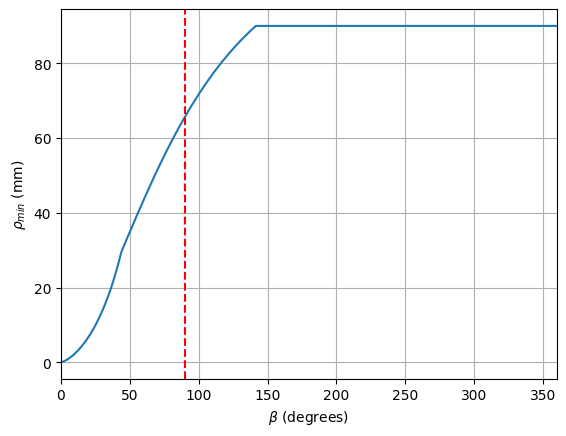

 rho_min when beta = 60°: 62.68 mm
 rho_min when beta = 60°: 62.78 mm
 rho_min when beta = 60°: 62.88 mm


<Figure size 640x480 with 0 Axes>

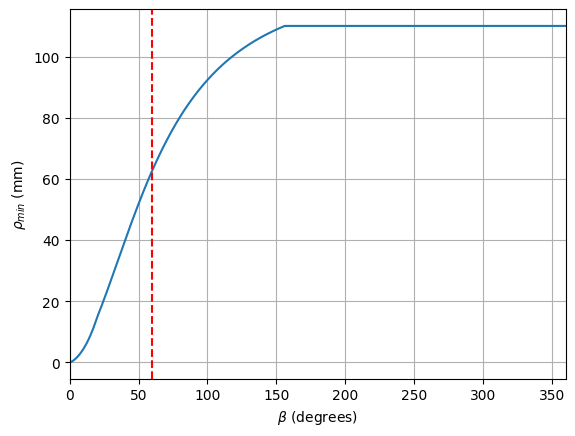

 rho_min when beta = 80°: 63.41 mm
 rho_min when beta = 80°: 63.47 mm
 rho_min when beta = 80°: 63.54 mm


<Figure size 640x480 with 0 Axes>

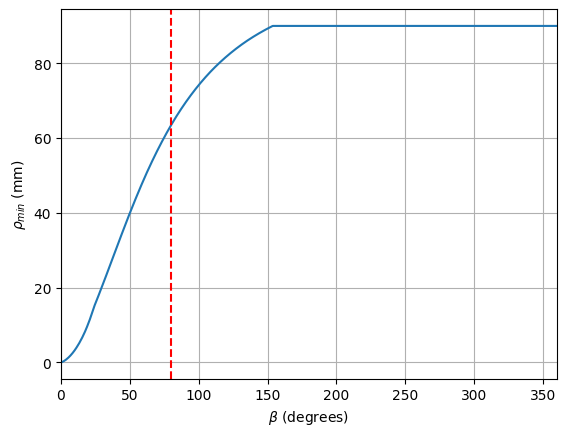

In [11]:
# Use the first Kloomok and Muffley figure to choose the follower radius Rr
# Segment 1: van 30° tot 120° : +40 mm
beta = endangle1 - startangle1  # cam angle interval in degrees
startlift = startlift1  # start lift in mm
endlift = endlift1 # end lift in mm
motionlaw = motionlaw1 # choice of motion law (1: dwell, 2: minimal rms acceleration, 3: harmonic, 4: cycloid, 5: 5th degree poly, 6: 7th degree poly)
# Plot the figure of segment 1
plt.figure(num = 'Kloomok and Muffley - segment 1')
Kloomok_Muffley_follower_radius(R0,startlift,endlift,motionlaw, beta)

# Segment 3 (skipping dwel segment 2): van 180° tot 240° : -20 mm
beta = endangle3 - startangle3 # cam angle interval in degrees
startlift = startlift3  # start lift in mm
endlift = endlift3 # end lift in mm
motionlaw = motionlaw3 # choice of motion law (1: dwell, 2: minimal rms acceleration, 3: harmonic, 4: cycloid, 5: 5th degree poly, 6: 7th degree poly)
# Plot the figure of segment 3
plt.figure(num = 'Kloomok and Muffley - segment 3')
Kloomok_Muffley_follower_radius(R0,startlift,endlift,motionlaw, beta)

# Segment 5 (skipping dwel segment 4): van 250° tot 330° : -20 mm
beta = endangle5 - startangle5 # cam angle interval in degrees
startlift = startlift5  # start lift in mm
endlift = endlift5 # end lift in mm
motionlaw = motionlaw5 # choice of motion law (1: dwell, 2: minimal rms acceleration, 3: harmonic, 4: cycloid, 5: 5th degree poly, 6: 7th degree poly)
# Plot the figure of segment 5
plt.figure(num = 'Kloomok and Muffley - segment 5')
Kloomok_Muffley_follower_radius(R0,startlift,endlift,motionlaw, beta)

As mentioned we are taking $R_r$ such that it is smaller than $\rho_{\text{min}}$ for every segment to prevent undercutting. Above plots give us the upperlimits $\rho_{\text{min}}$ for every segment:
- Segment 1 => $58.45$ mm
- Segment 3 => $55.76$ mm
- Segment 5 => $55.47$ mm

To ensure the condition $R_r$ should be smaller than $55.47$ mm, therefore we choose $R_r$ $45$ mm

In [12]:
R_r = 45 #mm

### Pressure angle and geometry check
Once the pitch radius and follower radius (and thus, base radius) are selected, the _calculatePressureAngle_ calculates the pressure angle along the whole cam motion to check if it stays within the desired limits (using the plot given by _plotPressureAngle_). Eventually, the pressure angle curve can be optimised by introducing excentricity in the mechanism. Therefore, the pressure angle can be calculated as:

$\alpha = arctan(\frac{f'(\theta)-e}{\sqrt{R_0^2-e^2}+f(\theta)})$

Furthermore, the radius of curvature of the pitch and cam curves are calculated in the _calculateRadiusCurvature_ function. The figure given by _plotRadiusCurvature_ can be used to verify that there is no undercutting in the mechanism. 

Finally, a sketch of the cam-follower mechanism is plotted using _plotCamContour_.

In [13]:
# Kinematics inputs
pitch_radius = R0 # pitch radius in mm
follower_radius = R_r # follower radius in mm

base_radius = R0 - R_r # base circle radius in mm
exc = 0 # excentricity in mm

print(f'Pitch radius: {pitch_radius} mm')
print(f'Follower radius: {follower_radius} mm')
print(f'Base circle radius: {base_radius} mm')

Pitch radius: 90 mm
Follower radius: 45 mm
Base circle radius: 45 mm


In [14]:
# utility functions for pressure angle

def calculatePressureAngle(vel,exc,base_radius,follower_radius,lift):
    pressure_angle = np.arctan((vel-exc)/(np.sqrt((base_radius+follower_radius)**2-exc**2)+lift))
    return pressure_angle

def plotPressureAngle(theta_deg,pressure_angle):
    plt.figure()
    plt.plot(theta_deg, pressure_angle*180/np.pi)
    plt.xlabel('rotation [deg]')
    plt.ylabel('Pressure angle [deg]')
    plt.xlim([0,360])

In [15]:
# utility functions for curvature radius

def calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2) #Nortron, Kinematic and dynamics of Machinery eq. 8.31c
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2 # Nortron, Kinematic and dynamics of Machinery eq. 8.34, adapted for vertical follower instead of a horizontal one (--> + pi/2)
    dlambda = -1 + exc/((d+lift)**2 + exc**2) * vel # derivative of lambda with repect to theta
    ddlambda = exc/((d+lift)**2 + exc**2)*acc - 2*exc*(d+lift)*vel**2/((d+lift)**2 + exc**2)**2 # 2nd derivative of lambda with repect to theta

    g = np.sqrt((d+lift)**2 + exc**2) 
    dg = vel*(d+lift)/np.sqrt((d+lift)**2 + exc**2) # derivative of g with repect to theta
    ddg = (vel**2  + acc*(d + lift))/np.sqrt((d + lift)**2 + exc**2) - (vel**2*(d + lift)**2)/((d + lift)**2 + exc**2)**(3/2) # 2nd derivative of g with repect to theta

    h = np.sin(lambda_)
    dh = np.cos(lambda_)*dlambda # derivative of h with repect to theta
    ddh = -np.sin(lambda_)*dlambda**2 + np.cos(lambda_)*ddlambda # 2nd derivative of h with repect to theta
    f = np.cos(lambda_)
    df = -np.sin(lambda_)*dlambda #derivative of f with repect to theta
    ddf = -np.cos(lambda_)*dlambda**2 - np.sin(lambda_)*ddlambda # 2nd derivative of f with repect to theta

    dx = df*g + f*dg #derivative of x with repect to theta
    ddx = ddf*g + 2*df*dg + f*ddg # 2nd derivative of x with repect to theta
    dy = dh*g + h*dg # derivative of y with repect to theta
    ddy = ddh*g + 2*dh*dg + h*ddg # 2nd derivative of y with repect to theta

    roc_pitch = -(dx**2 + dy**2)**(3/2) / (dx*ddy - dy*ddx) # general forumula for the radius of curvature
    roc_cam = roc_pitch - follower_radius

    return roc_pitch, roc_cam

def plotRadiusCurvature(theta_deg,roc_pitch,roc_cam):
    inds = np.where(np.abs(np.diff(roc_pitch)/dtheta)<1e3)[0]
    maxi = max(10, max(roc_pitch[inds+1]))
    mini = min(-10, min(roc_pitch[inds+1]))
    plt.figure()
    plt.plot(theta_deg, roc_pitch)
    plt.plot(theta_deg, roc_cam)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Radius of curvature [mm]')
    plt.xlim([0,360])
    plt.ylim([mini,maxi])
    plt.grid()
    plt.title('Radius of curvature')

    plt.figure()
    plt.plot(theta_deg, roc_pitch)
    plt.plot(theta_deg, roc_cam)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Radius of curvature [mm] (zoomed in)')
    plt.xlim([0,360])
    plt.ylim([-30,30])
    plt.grid()
    plt.title('Radius of curvature')

def plotCamContour(base_radius, follower_radius, exc, theta, lift, pressure_angle, dtheta):
    # --- Original Calculations (unchanged) ---
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2)
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2
    xpitch = np.cos(lambda_)*np.sqrt((d+lift)**2 + exc**2)
    ypitch = np.sin(lambda_)*np.sqrt((d+lift)**2 + exc**2)

    xcam = xpitch + follower_radius*np.cos(-theta + pressure_angle + 3*np.pi/2)
    ycam = ypitch + follower_radius*np.sin(-theta + pressure_angle + 3*np.pi/2)

    pitch_curve = np.array([xpitch, ypitch])
    cam_curve = np.array([xcam, ycam])

    x_rolfol_center = exc  
    y_rolfol_center = d + lift[0]  
    x_rolfol = follower_radius * np.cos(theta) + x_rolfol_center  
    y_rolfol = follower_radius * np.sin(theta) + y_rolfol_center  

    min_distance_center_roller_to_bore = 2 * follower_radius
    height_bore = follower_radius
    width_block_on_follower = base_radius / 2
    height_block_on_follower = base_radius / 2

    x_boreleft = np.array([exc - 5, exc - 1, exc - 1, exc - 5])
    x_boreright = np.array([exc + 5, exc + 1, exc + 1, exc + 5])
    y_bore = np.array([d + max(lift) + min_distance_center_roller_to_bore] * 2 + 
                      [d + max(lift) + min_distance_center_roller_to_bore + height_bore] * 2)
    
    length_follower = y_bore[-1] - ypitch[0] - follower_radius + 0.2

    x_follower = np.array([x_rolfol_center, x_rolfol_center])
    y_follower = np.array([y_rolfol_center + follower_radius, y_rolfol_center + follower_radius + length_follower])

    x_block_on_follower = np.array([-width_block_on_follower, width_block_on_follower, width_block_on_follower, -width_block_on_follower]) + x_follower[0]
    y_block_on_follower = np.array([0, 0, height_block_on_follower, height_block_on_follower]) + y_follower[1]

    ref_line = np.array([[0, 0], [0, base_radius]])

    x_pressangle = np.array([x_rolfol_center + follower_radius * np.sin(pressure_angle[0]), 
                             x_rolfol_center - follower_radius * np.sin(pressure_angle[0])])
    y_pressangle = np.array([y_rolfol_center - follower_radius * np.cos(pressure_angle[0]), 
                             y_rolfol_center + follower_radius * np.cos(pressure_angle[0])])

    # --- Plotting with 180-degree rotation (Negating coordinates) ---
    plt.figure()
    
    # Negate coordinates: x -> -x and y -> -y
    plt.fill(-cam_curve[0, ::int(1 / dtheta)], -cam_curve[1, ::int(1 / dtheta)], 'b', label='Cam')
    plt.fill(-x_rolfol[::int(1 / dtheta)], -y_rolfol[::int(1 / dtheta)], 'g', label='Roller')
    plt.plot(-pitch_curve[0, ::int(1 / dtheta)], -pitch_curve[1, ::int(1 / dtheta)], '--r', label='Pitch Curve')
    
    plt.plot(0, 0, 'r+') # Origin stays at (0,0)
    plt.plot(-x_pressangle, -y_pressangle, 'r--')
    plt.plot(-ref_line[0, :], -ref_line[1, :], 'r--')
    plt.plot(-x_boreleft, -y_bore, 'r')
    plt.plot(-x_boreright, -y_bore, 'r')
    plt.plot(-x_follower, -y_follower, 'r')
    plt.fill(-x_block_on_follower, -y_block_on_follower, 'g')

    # --- Adjust Limits for the Rotated View ---
    # The original top components (positive Y) are now at the bottom (negative Y)
    xlimits = [min(-pitch_curve[0, :]), max(-pitch_curve[0, :])]
    ylimits = [-(d + max(lift) + follower_radius + length_follower + height_block_on_follower), 
               max(-pitch_curve[1, :])]

    plt.xlim(np.array(xlimits) * 1.2)
    plt.ylim(np.array(ylimits) * 1.05)
    plt.gca().set_aspect('equal')
    plt.grid(True)
    plt.title('Cam contour [mm] - Rotated 180°')

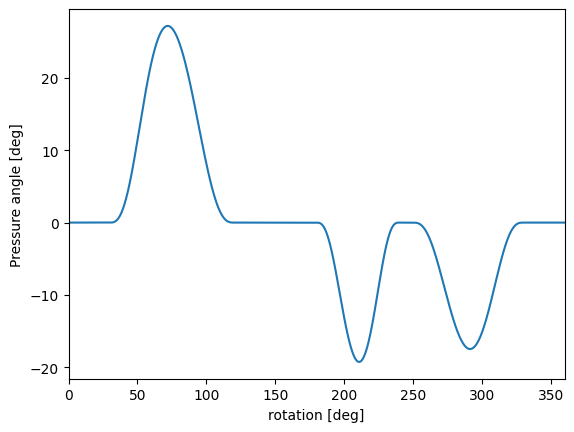

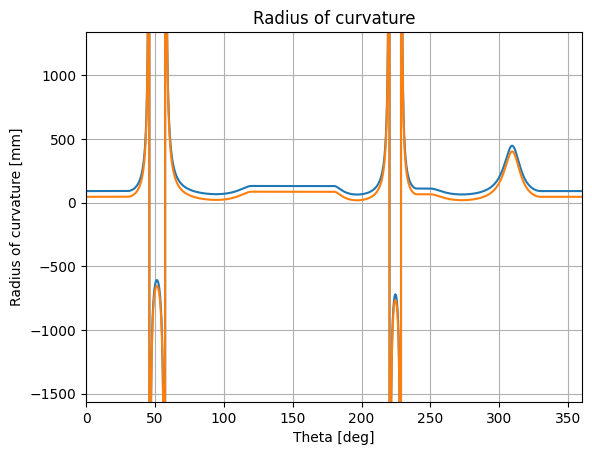

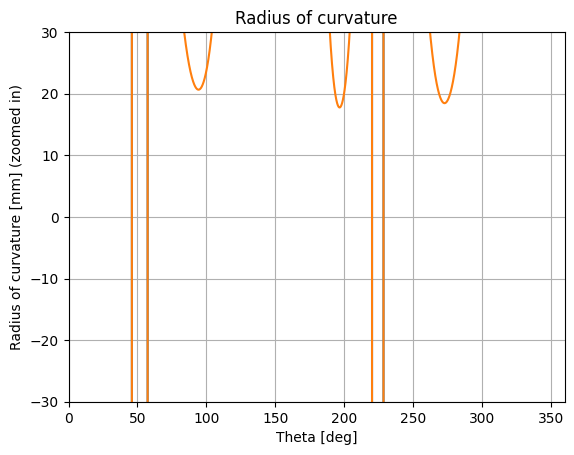

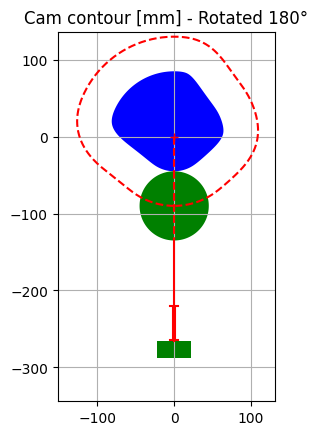

In [16]:
# Calculate pressure angle
pressure_angle = calculatePressureAngle(vel,exc,base_radius,follower_radius,lift)

# Plot pressure angle
plotPressureAngle(theta_deg,pressure_angle)

# Calculate radius of curvature
roc_pitch, roc_cam = calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc)

# Plot the radius of curvature
plotRadiusCurvature(theta_deg,roc_pitch,roc_cam)

# Plot the cam contour
plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta)

On above plots we can see that the radius of curvature stays with enough margin away from 0 mm. Undercutting is prevented. If margin has to be increased, this can be realised by increasing $R_0$ or by decreasing $R_r$. We see spikes in curvature, but this is locally/instantaneous due to change from convex to concave. This can be seen on the cam contour. Additionally we can observe a pressure angle approaching 30°, during the first uplift. This demonstrates a somewhat inefficient force transmission at that point. If there is enough place and we do not take care of additional material cost, this pressure angle could be decreased by increasing $R_0$. Alternatively, if assymetry is not a problem and friction forces are much higher in uplift than downlift, excentricity could be added to reduce this pressure angle in the uplift. This may cause more difficult assembly too.

With excentricity, eventually, depended on forces, symmetry, friction importance (has to be seen later)...

Example underneath:

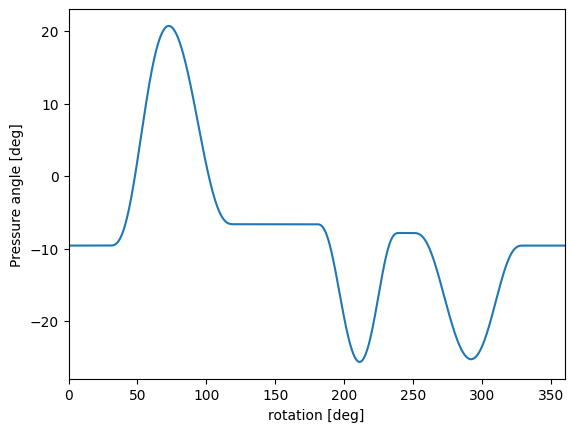

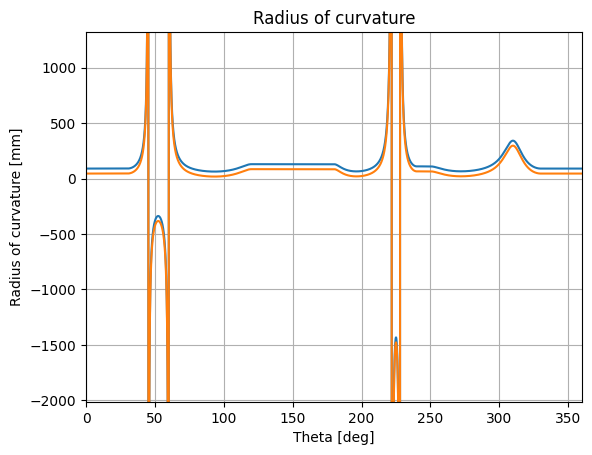

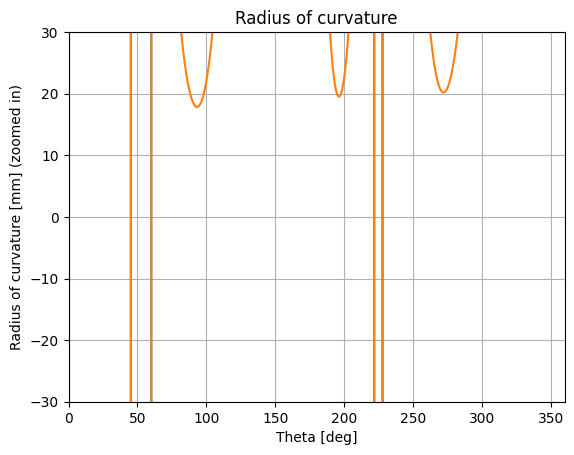

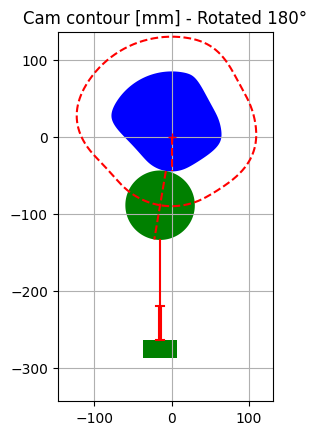

In [17]:
# Kinematics inputs
exc = 15 # excentricity in mm
exc_non_zero = exc

# Calculate pressure angle
pressure_angle_exc = calculatePressureAngle(vel,exc,base_radius,follower_radius,lift)

# Plot pressure angle
plotPressureAngle(theta_deg,pressure_angle_exc)

# Calculate radius of curvature
roc_pitch_exc, roc_cam_exc = calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc)

# Plot the radius of curvature
plotRadiusCurvature(theta_deg,roc_pitch_exc,roc_cam_exc)

# Plot the cam contour
plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle_exc,dtheta)

## Forces acting on the follower
In this section we compute all forces acting on the follower and we choose spring parameters (preload and springconstant) such that constant contact between cam and follower is guaranteed. Therefore the total normal force acting on the follower must be > 0. We choose y-axis in upwards-vertical direction and x-axis in right-horizontal direction.

<div style="display: grid; grid-template-columns: 1fr 3fr; grid-column-gap: 1%;">
<div style="height: 20rem;">
<img style="border: 0; display: inline-block;" height="100%"
      src="../figures/cam-forces.png"
>
</div>
<div>

Keep in mind that the drawing left has to be rotated 180° as our follower is configured going down for positive lift (see cam figure in prouvious section). We can resume forces acting on the follower in the y-axis, when follower is moving down (positive lift):
- Positive:
    - Spring force ($F_v$)
    - Friction ($\mu R$)
    - Load ($F_{func}$)
    - Damping ($c v_y$)
- Negative:
    - Inertial force ($m a_y$)
    - Gravity ($m g$)

Solving this including friction requires a sytem of 2 equations and 2 unknowns ($N$ and $R$):

$
\begin{aligned}
N\, \cos(\alpha) = F_{\text{func}} + F_v + m \frac{d^2y}{dt^2} + c \frac{dy}{dt}+ m\, g\ + \mu R \\
N\, \sin(\alpha) = R
\end{aligned}
$

=> $ N = \frac{F_{\text{func}} + F_v + m \frac{d^2 y}{dt^2} + c \frac{dy}{dt} + m g}{\cos(\alpha) - \mu \sin(\alpha)}$ and $R = N \sin(\alpha)$

In underneath code, the forces are computed and plotted. When plotting the forces, the critical spring stiffness at each cam angle (guaranteeing a positive normal force) is plotted too. Afterwards the maximum of this plot (in the useful interval) is printed and used to reiterate the spring constant for a given preload. The lift must not be zero. It comes from this formula:

$$
k_v  = \max_{\theta} \frac{- F_{v0} -F_{\text{func}} - m \omega^2 \frac{d^2 S(\theta)}{d\theta^2} - c \omega \frac{dS(\theta)}{d\theta} - mg -\mu R}{S(\theta)}.
$$

Every $k_v$ above this value will guarantee cam-follower contact.

In [18]:
def calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc,damping,vel,mu,safety_factor,g=9.81):

    omega = (1+safety_factor)*rpm*2*np.pi/60

    normalforce_spring = (lift*spring_constant+spring_preload)/np.cos(pressure_angle) # force from the spring, corrected for the pressure angle
    normalforce_load = ext_load/np.cos(pressure_angle) # force from the external load, corrected for the pressure angle
    normalforce_acc = mass*acc/1000*(omega**2)/np.cos(pressure_angle) # force from the acceleration of the follower, corrected for the pressure angle
    zwaartekracht = (mass*g)/np.cos(pressure_angle) # force from the weight of the follower, corrected for the pressure angle
    damp_force = damping*vel/1000*omega/np.cos(pressure_angle) # force from the damping, corrected for the pressure angle
    # Sign convention for positive lift
    normalforce_0_fric = normalforce_spring + normalforce_load - normalforce_acc - zwaartekracht + damp_force # force on the follower without friction, corrected for the pressure angle
    normalforce_tot = (normalforce_0_fric*np.cos(pressure_angle))/(np.cos(pressure_angle)-mu*np.sin(pressure_angle)) # total normal force on the follower, corrected for the pressure angle and friction
    force_x = normalforce_tot * np.sin(pressure_angle) # force in the x direction 
    friction_force =(mu*force_x)/np.cos(pressure_angle) # friction force
    force_y = normalforce_tot * np.cos(pressure_angle) # force in the y direction


    # Calculate max equivakent spring stiffness so that F_nom > 0
    k_v = (-spring_preload - ext_load + normalforce_acc*np.cos(pressure_angle)+zwaartekracht*np.cos(pressure_angle)-damp_force*np.cos(pressure_angle)-friction_force*np.cos(pressure_angle))
    k_v_filtered = np.zeros_like(k_v, dtype=float)
    # Consider the range where the lift is not zero and k_v is computable (50° => 5000 , 325° => 32500)
    k_v_filtered[5000:32500] = k_v[5000:32500] / lift[5000:32500]

    return normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y,zwaartekracht,damp_force, friction_force, k_v_filtered

def plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y,zwaartekracht,damp_force, friction_force, k_v_filtered):
    plt.figure()
    plt.plot(theta_deg,normalforce_tot)
    plt.plot(theta_deg,-normalforce_acc,'--r')
    plt.plot(theta_deg,normalforce_load,':g')
    plt.plot(theta_deg,normalforce_spring,'-.m')
    plt.plot(theta_deg,-zwaartekracht,'-.c')
    plt.plot(theta_deg,damp_force,'-.b')
    plt.plot(theta_deg,friction_force,'-.g')
    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0,360])
    plt.legend(['total','acc','extload','spring','gravity','damping','friction'])
    plt.title('Normal force')

    plt.figure()
    plt.plot(theta_deg,force_x)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force x [N]')
    plt.xlim([0,360])
    plt.title('Force x')

    plt.figure()
    plt.plot(theta_deg,force_y)
    # plt.plot(theta_deg,normalforce_tot)
    # plt.plot(theta_deg,-np.sqrt(force_x**2+force_y**2))
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force y [N]')
    plt.xlim([0,360])
    plt.title('Force y')

    plt.figure()
    plt.plot(theta_deg,k_v_filtered)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Critical spring stiffness [N/mm]')
    plt.xlim([50,325])
    plt.title('Critical spring stiffness')


In [19]:
# utility functions for external load

def addLoadSegment(startangleload,endangleload,startload,endload,dtheta):
    assert startangleload - endangleload < 0, 'End angle should be bigger than start angle'
    start_index = int(startangleload/dtheta)
    end_index = int(endangleload/dtheta)
    theta_segment = theta_deg[start_index:end_index]
    ext_load[start_index:end_index] = (endload - startload)/(endangleload - startangleload)*(theta_segment - startangleload) + startload

    return ext_load

def plotExternalLoad(theta_deg,ext_load):
    plt.figure()
    plt.plot(theta_deg, ext_load)
    plt.xlabel('Theta [deg]')
    plt.ylabel('External load [N]')
    plt.xlim([0,360])
    plt.title('External load')


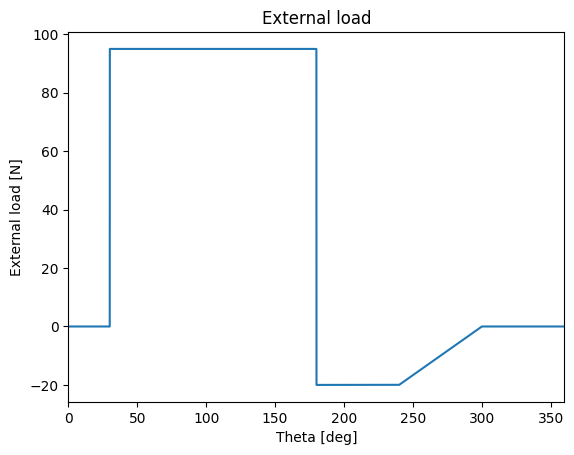

In [20]:
# generate external load

ext_load = addLoadSegment(startangleload1,endangleload1,startload1,endload1,dtheta)
ext_load = addLoadSegment(startangleload2,endangleload2,startload2,endload2,dtheta)
ext_load = addLoadSegment(startangleload3,endangleload3,startload3,endload3,dtheta)

plotExternalLoad(theta_deg,ext_load)

The dynamic inputs are set underneath and used to compute all forces acting on the follower. Firstly the spring preload is chosen such that the normal force is positive with a certain margin at zero lift. Afterwards a max $k_v$ is printed and every spring constant above that value can be used to guarantee cam-follower contact along the hole process.

You should notice that a safety_factor is also being used. This sets the allowed variation on motor speed and will be useful for designing a flywheel in next section. All forces are computed with inclusion of this variation to ensure the mechanism can still function properly even if the rpm is higher than expected. 

Maximum critical spring stiffness: 11.276620974936185 N/mm
Indices where normal force is negative: []
Minimum normal force: 0.00757150615379005 N
Maximum normal force: 575.6435393002419 N
Average normal force: 268.25127553785035 N


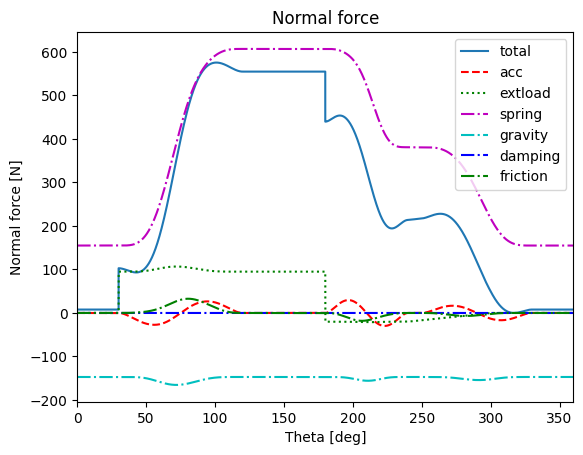

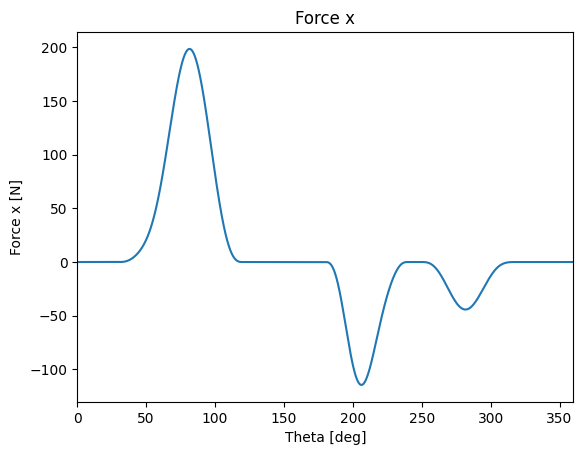

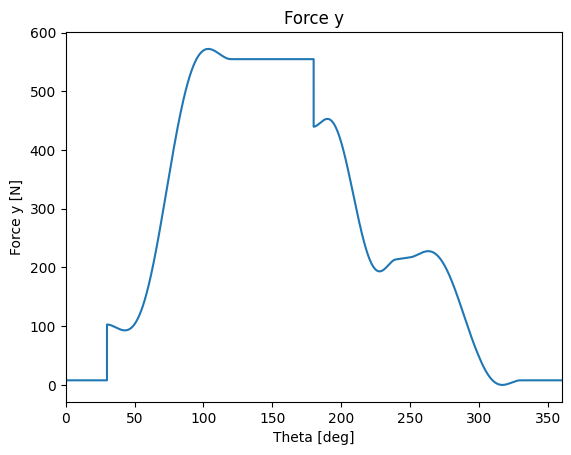

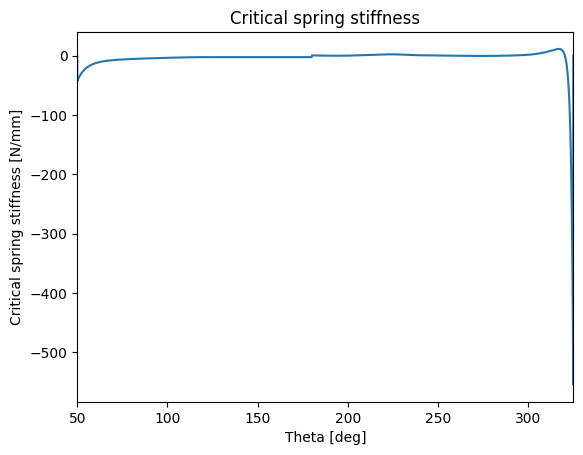

In [21]:
# spring design

# dynamic inputs
mass            =  15
spring_constant = 11.3 # N/mm > 11.276620974936185 for positive normal force
spring_preload  = 155 # See marging with 15kg*9.81m/s^2 = 147.15N
rpm             = 30
damping = 0.054
mu = 0.15
safety_factor = 0.2 # variation of 20% in the rpm to account for uncertainties in the actual operating conditions (e.g. variations in the motor speed, changes in the load, etc.) and to ensure that the cam mechanism can still function properly even if the actual rpm is higher than expected.
# Calculate forces
[normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y,zwaartekracht,damp_force,friction_force, k_v_filtered] = calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc,damping,vel,mu,safety_factor)
# Plot forces
plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y,zwaartekracht,damp_force, friction_force, k_v_filtered)

print(f'Maximum critical spring stiffness: {max(k_v_filtered[5000:32500])} N/mm')
print(f'Indices where normal force is negative: {[i for i in range(len(normalforce_tot)) if normalforce_tot[i] < 0]}')
print(f'Minimum normal force: {min(normalforce_tot)} N')
print(f'Maximum normal force: {max(normalforce_tot)} N')
print(f'Average normal force: {np.mean(normalforce_tot)} N')

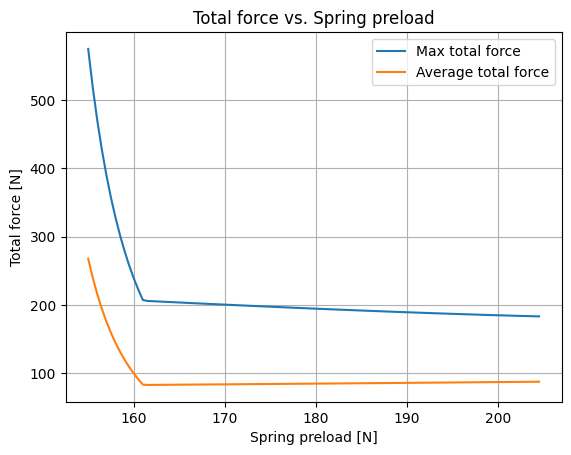

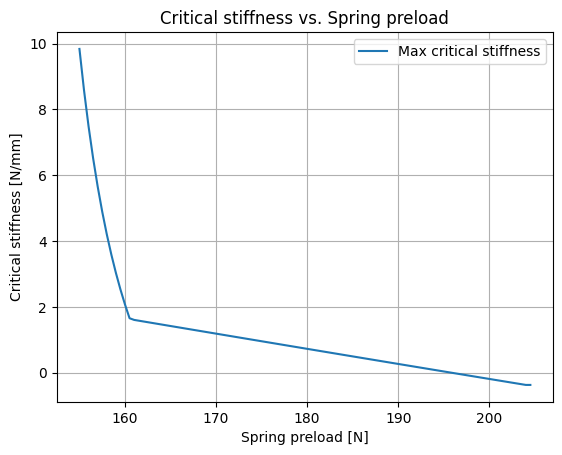

Optimal preload: 161.5 N for min avg total force: 82.93459585567896 N and critical stiffness: 1.5824831509258859 N/mm


In [22]:
# Preload optimizer
def optimizePreload(rpm,lift,spring_constant_start,spring_preload_start,spring_preload_end,pressure_angle,ext_load,mass,acc,damping,vel,mu,safety_factor):
    preloads = np.arange(spring_preload_start, spring_preload_end, 0.5)
    max_total_forces = np.zeros_like(preloads)
    avg_total_forces = np.zeros_like(preloads)
    max_critical_stiffness = np.zeros(len(preloads)+1)
    max_critical_stiffness[0] = spring_constant_start
    for i in range(len(preloads)):
        spring_preload = preloads[i]
        for j in range(10): # iterate to find the maximum critical stiffness for the given preload
            _,_,_,_,_,_,_,_,_,k_v_filtered = calculateForce(rpm,lift,max_critical_stiffness[i],spring_preload,pressure_angle,ext_load,mass,acc,damping,vel,mu,safety_factor)
            max_critical_stiffness[i] = max(k_v_filtered[5000:32500])
        normalforce_tot,_,_,_,_,_,_,_,_,k_v_filtered = calculateForce(rpm,lift,max_critical_stiffness[i],spring_preload,pressure_angle,ext_load,mass,acc,damping,vel,mu,safety_factor)
        max_total_forces[i] = max(normalforce_tot)
        avg_total_forces[i] = np.mean(normalforce_tot)
        max_critical_stiffness[i+1] = max(k_v_filtered[5000:32500])
    return preloads, max_total_forces, avg_total_forces, max_critical_stiffness

spring_constant_start = 11.3 # N/mm > 11.276620974936185 for positive normal force
spring_preload_start = 155 # See marging with 15kg*9.81m/s^2 = 147.15N
spring_preload_end = 205 # N

preloads, max_total_forces, avg_total_forces, max_critical_stiffness = optimizePreload(rpm,lift,spring_constant_start,spring_preload_start,spring_preload_end,pressure_angle,ext_load,mass,acc,damping,vel,mu,safety_factor)
plt.figure()
plt.plot(preloads, max_total_forces, label='Max total force')
plt.plot(preloads, avg_total_forces, label='Average total force')
plt.xlabel('Spring preload [N]')
plt.ylabel('Total force [N]')
plt.title('Total force vs. Spring preload')
plt.legend()
plt.grid()
plt.figure()
plt.plot(preloads, max_critical_stiffness[1:], label='Max critical stiffness')
plt.xlabel('Spring preload [N]')
plt.ylabel('Critical stiffness [N/mm]')
plt.title('Critical stiffness vs. Spring preload')
plt.legend()
plt.grid()  
plt.show()

print(f'Optimal preload: {preloads[np.argmin(avg_total_forces)]} N for min avg total force: {min(avg_total_forces)} N and critical stiffness: {max_critical_stiffness[np.argmin(avg_total_forces)+1]} N/mm')
    

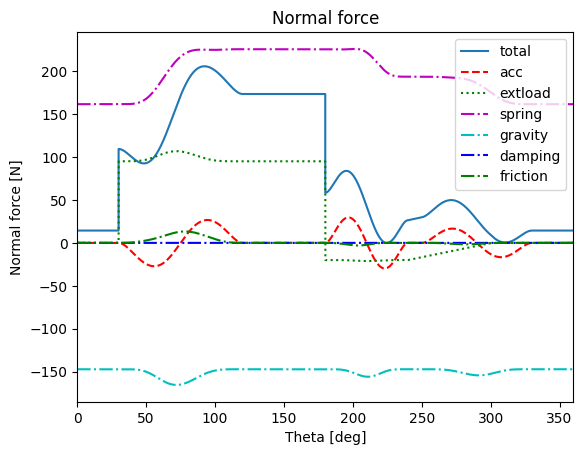

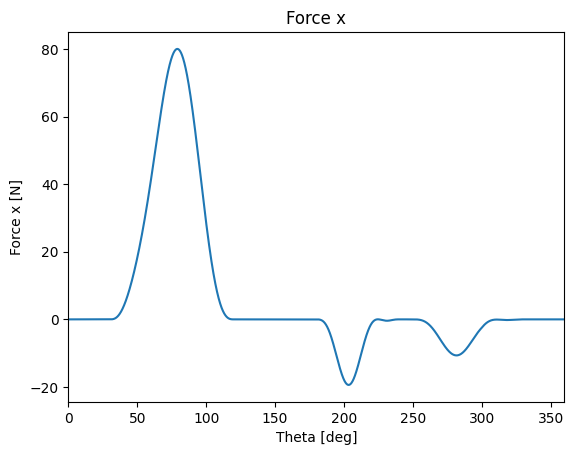

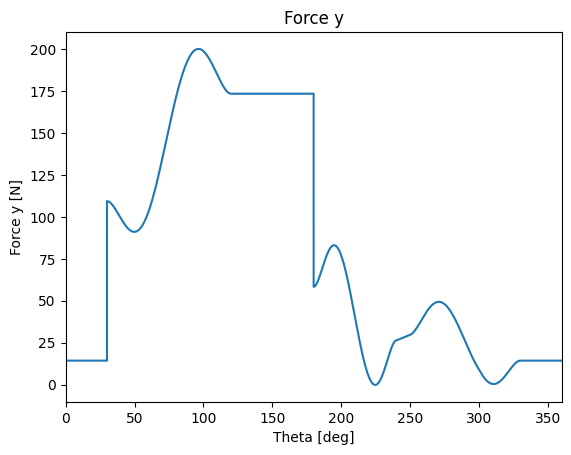

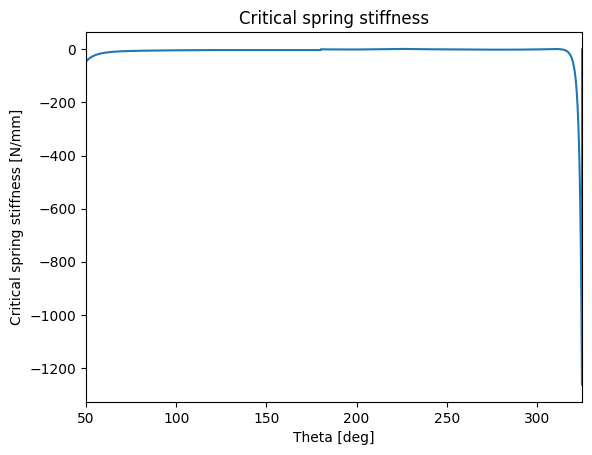

In [23]:
spring_constant = 1.6 # N/mm > 1.5824831509258859 for positive normal force
spring_preload  = 161.5 # N See marging with 15kg*9.81m/s^2 = 147.15N
# Calculate forces with optimized preload
[normalforce_tot_opt,normalforce_acc_opt,normalforce_load_opt,normalforce_spring_opt,force_x_opt,force_y_opt,zwaartekracht_opt,damp_force_opt,friction_force_opt, k_v_filtered_opt] = calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc,damping,vel,mu,safety_factor)
# Plot forces with optimized preload
plotForces(theta_deg,normalforce_tot_opt,normalforce_acc_opt,normalforce_load_opt,normalforce_spring_opt,force_x_opt,force_y_opt,zwaartekracht_opt,damp_force_opt, friction_force_opt, k_v_filtered_opt)

## Energy load, regime and flywheel

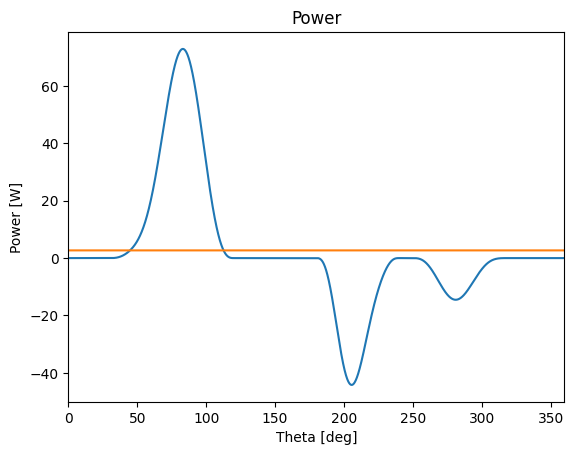

2.686508193292959
6.529707414253719e-07
7.182678155679091
0.855142117238903


In [24]:
#Power
R=R0+lift #mm
omega=rpm*2*np.pi*(1/60)
P=normalforce_tot*np.sin(pressure_angle)*R*1e-3*omega
plt.figure()
plt.plot(theta_deg,P)
plt.plot(theta_deg,np.mean(P)*np.ones(len(P)))
plt.xlabel('Theta [deg]')
plt.ylabel('Power [W]')
plt.xlim([0,360])
plt.title('Power')
plt.show()
print(np.mean(P))
Energy_mechanisme=np.mean(P)*2

efficiency_motor=0.8
Energy_motor_per_cyclus_j=Energy_mechanisme/efficiency_motor
Energy_motor_per_cyclus_kwh=Energy_motor_per_cyclus_j/3600000
Cost_kwh=0.35
Cost_per_cyclus=Energy_motor_per_cyclus_kwh*Cost_kwh
print(Cost_per_cyclus)
cycly_er_jaar=11000000
yealry_cost=Cost_per_cyclus*cycly_er_jaar
print(yealry_cost)
M_gem=np.mean(P)/omega
print(M_gem)

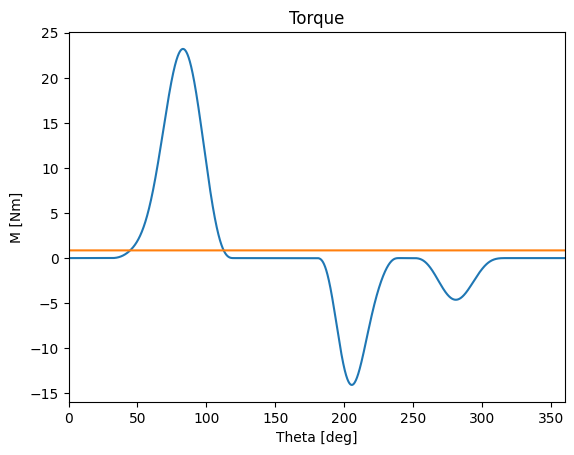

360.0


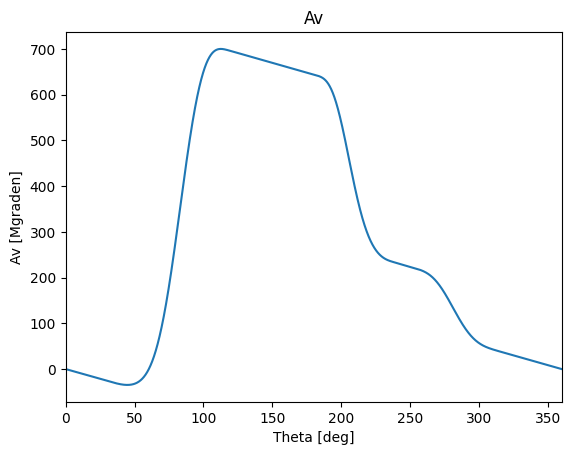

3.248120766691941


In [55]:
#vliegwiel
#moment
M=P/omega
plt.figure()
plt.plot(theta_deg,M, label='Torque (M)')
plt.plot(theta_deg,M_gem*np.ones(len(P)))
plt.xlabel('Theta [deg]')
plt.ylabel('M [Nm]')
plt.xlim([0,360])
plt.title('Torque')
plt.show()
print(len(M)*0.01)
f=M-M_gem*np.ones(len(P))
Av=np.zeros(len(M))
for i in range(len(M)):
    Av[i]=np.mean(f[0:i+1])*(i+1)*0.01

plt.figure()
plt.plot(theta_deg,Av)
plt.xlabel('Theta [deg]')
plt.ylabel('Av [Mgraden]')
plt.xlim([0,360])
plt.title('Av')
plt.show()



theta_m = np.argmin(Av) 
theta_M = np.argmax(Av)

min_waarde = Av[theta_m] 
max_waarde = Av[theta_M]

K=0.4# 20% flucutaties

I=(np.mean(f[theta_m:theta_M])*(theta_M-theta_m)*0.01*(np.pi/180))/(K*omega*omega)
print(I)


0.11800000000000004 1.3586719366447524


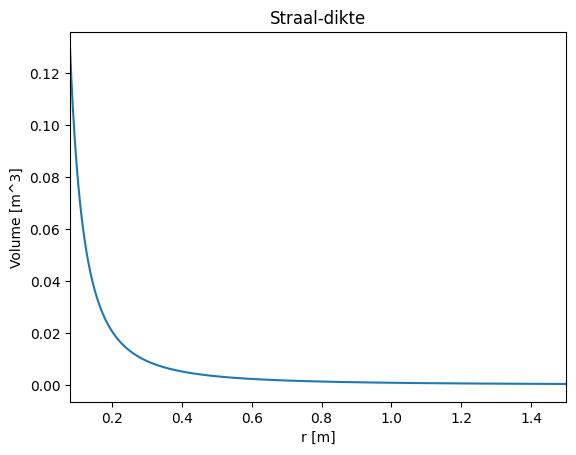

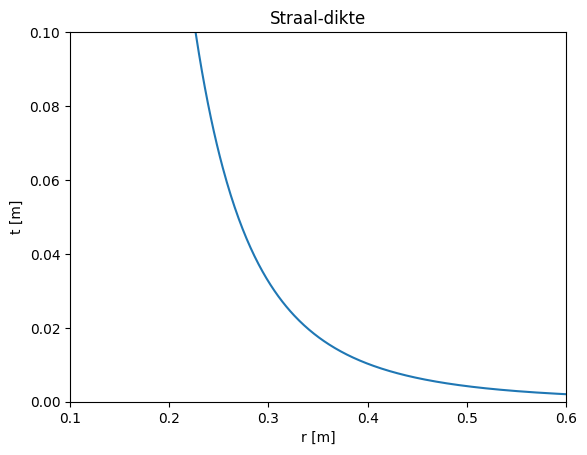

In [44]:
#schijf
rho=7850 #staal, kg/m^3
r=np.arange(0.08,20000,0.001)
t=(2*I)/(np.pi*((r)**4) * rho)
volume=np.pi*r**2*t
target_def = -1
target_index = 0
for i in range(len(r)-1):
    if (volume[i+1] - volume[i])/(r[i+1] - r[i]) > target_def:
        target_index = i
        break
print(r[target_index],t[target_index])
plt.figure()
plt.plot(r, volume)
plt.xlabel('r [m]')
plt.ylabel('Volume [m^3]')
plt.xlim([0.08,1.5])
plt.title('Straal-dikte')
plt.figure()
plt.plot(r, t)
plt.xlabel('r [m]')
plt.ylabel('t [m]')
plt.xlim([0.1,0.6])
plt.ylim([0,0.1])
plt.title('Straal-dikte')
plt.show()



In [47]:
# choose r = 0.3m
r_chosen = 0.3
t_chosen = (2*I)/(np.pi*((r_chosen)**4) * rho)
print(f'Chosen radius: {r_chosen} m, Thickness: {t_chosen} m, Mass: {rho*np.pi*r_chosen**2*t_chosen} kg')

Chosen radius: 0.3 m, Thickness: 0.03252053004818491 m, Mass: 72.18046148204314 kg
